# Step 1 — Case-Operate / Operating-State Resolution
**CPHT Fouling→CIT project · Plant 3 TPU** — implements Step 1 of `docs/02_Requirement_v2_SSOT.md`.

Ports the operating-state logic from `2a_operating_state_classification.ipynb` (unchanged thresholds)
and **adds one canonical column `residue_chain_case`** that every downstream Step reads, matching the
LOCKED case-operate rules:

| case | meaning | HX running |
|---|---|---|
| `NORMAL` | E113A active, E112C idle | E113A → E112AB → E108AB |
| `E113A_CLEANING` | E113A idle, **E112C substitutes** | E112C → E112AB → E108AB |
| `E112AB_CLEANING` | E112AB bypassed, **E113A + E112C both run** | E113A + E112C → E108AB |
| `PARALLEL` | both active, not a bypass | both → E112AB → E108AB |
| `CHAIN_OFF_ERROR` | neither active (QA flag — should be 0) | — |

Plus CPHT-1 `e101ef_case`: `NORMAL / OFF / SUBSTITUTED_BY_E101G` (E101G offline, inferred by mass balance).

> `E112C_CLEANING` cannot be separated from `NORMAL` from process data alone — needs the maintenance/cleaning log. Flagged where relevant.


## 1.1 Paths (work on the plant laptop AND in review sandbox)

In [1]:
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi']=100; plt.rcParams['font.size']=10

# robust base-dir detection (Windows plant machine OR linux review mount)
DATA_CANDS = [r'C:\Desktop\Bangchak Internship 2026\Data',
              '/sessions/dazzling-relaxed-davinci/mnt/Bangchak Internship 2026/Data']
NB_CANDS   = [r'C:\Desktop\Bangchak Internship 2026\furnace-optimization\notebooks',
              '/sessions/dazzling-relaxed-davinci/mnt/furnace-optimization/notebooks']
FIG_CANDS  = [r'C:\Desktop\Bangchak Internship 2026\furnace-optimization\figures\features',
              '/sessions/dazzling-relaxed-davinci/mnt/furnace-optimization/figures/features']
DATA_DIR = next(p for p in DATA_CANDS if os.path.exists(p))
NB_DIR   = next(p for p in NB_CANDS  if os.path.exists(p))
FIG_DIR  = next(p for p in FIG_CANDS if os.path.exists(p))
sys.path.append(NB_DIR)
print("DATA_DIR:", DATA_DIR)

DATA_DIR: /sessions/dazzling-relaxed-davinci/mnt/Bangchak Internship 2026/Data


## 1.2 Load cleaned process data + config (single source of truth)

In [2]:
from cpht_config import CPHT_1_HX, CPHT_2_HX
FILEPATH = os.path.join(DATA_DIR, 'Process_information_with_crude.csv')
df = pd.read_csv(FILEPATH, index_col=0, parse_dates=True)
print("Shape:", df.shape, "| range:", df.index.min().date(), "->", df.index.max().date())
print("CPHT-1:", CPHT_1_HX)
print("CPHT-2:", CPHT_2_HX)

Shape: (836, 103) | range: 2024-01-01 -> 2026-06-02
CPHT-1: ['E101AB', 'E101CD', 'E101EF', 'E101G', 'E102']
CPHT-2: ['E106AB', 'E110ABC', 'E103AB', 'E107AB', 'E111', 'E104', 'E108AB', 'E112AB', 'E105AB', 'E112C', 'E109AB', 'E113A']


## 1.3 CPHT-1 — E101EF ↔ E101G (mass-balance inference, unchanged from 2a)
E101G is an offline spare with **no instrumentation**: infer it runs from the crude mass balance.

In [3]:
FLOW_OFF_THRESH = 10.0    # m3/hr: branch considered not flowing
G_ACTIVE_THRESH = 30.0    # m3/hr: mass-balance gap large enough = real diversion to E101G

branch_flow = df[['1FI007.pv','1FI008.pv','1FI009.pv']].rename(
    columns={'1FI007.pv':'E101AB','1FI008.pv':'E101CD','1FI009.pv':'E101EF'})
total_charge = df['1fi005.pv']
branch_off = branch_flow < FLOW_OFF_THRESH
flow_G_inferred = (total_charge - branch_flow.sum(axis=1))
e101g_active = branch_off.any(axis=1) & (flow_G_inferred > G_ACTIVE_THRESH)

e101ef_case = np.where(branch_off['E101EF'] & e101g_active, 'SUBSTITUTED_BY_E101G',
               np.where(branch_off['E101EF'], 'OFF', 'NORMAL'))
print("E101G inferred-active days:", int(e101g_active.sum()), "/", len(df))
print("E101EF case counts:", pd.Series(e101ef_case).value_counts().to_dict())

E101G inferred-active days: 136 / 836
E101EF case counts: {'NORMAL': 700, 'SUBSTITUTED_BY_E101G': 136}


## 1.4 CPHT-2 residue chain — E113A ∥ E112C detection (unchanged thresholds)

In [4]:
SHELL_ACTIVE_TEMP_THRESH = 150.0   # degC: idle shell sits near-ambient
E112AB_BYPASS_DT_THRESH  = 10.0    # degC: E112AB near-zero duty => bypassed

e113a_active = df['1TI117.pv']  > SHELL_ACTIVE_TEMP_THRESH
e112c_active = df['1TI117B.pv'] > SHELL_ACTIVE_TEMP_THRESH
effective_hot_in_e112ab = df[['1TI117.pv','1TI117B.pv']].max(axis=1)
dt_e112ab = effective_hot_in_e112ab - df['1TI127.pv']
e112ab_bypass = (e113a_active & e112c_active) & (dt_e112ab < E112AB_BYPASS_DT_THRESH)

print(f"E113A active: {int(e113a_active.sum())} | E112C active: {int(e112c_active.sum())} "
      f"| both: {int((e113a_active&e112c_active).sum())} | neither: {int((~e113a_active&~e112c_active).sum())}")

E113A active: 732 | E112C active: 280 | both: 176 | neither: 0


## 1.5 Build the canonical `residue_chain_case` (LOCKED rules)

In [5]:
def residue_case(e113a, e112c, bypass):
    if bypass:                     return 'E112AB_CLEANING'      # both run, E112AB bypassed
    if e113a and not e112c:        return 'NORMAL'               # (or E112C_CLEANING — needs log)
    if e112c and not e113a:        return 'E113A_CLEANING'       # E112C substitutes
    if e113a and e112c:            return 'PARALLEL'
    return 'CHAIN_OFF_ERROR'

residue_chain_case = [residue_case(a,c,b) for a,c,b in zip(e113a_active, e112c_active, e112ab_bypass)]
residue_chain_case = pd.Series(residue_chain_case, index=df.index, name='residue_chain_case')
print(residue_chain_case.value_counts().to_dict())

{'NORMAL': 556, 'PARALLEL': 176, 'E113A_CLEANING': 104}


## 1.6 QA — hard invariants

In [6]:
n_chain_off = int((residue_chain_case=='CHAIN_OFF_ERROR').sum())
print("CHAIN_OFF_ERROR days (must be ~0):", n_chain_off)
assert n_chain_off <= max(3, int(0.01*len(df))), "Residue chain has too many both-off days — investigate sensors!"
# E113A NORMAL+CLEANING must cover all non-error, non-parallel days
cover = residue_chain_case.isin(['NORMAL','E113A_CLEANING','E112AB_CLEANING','PARALLEL']).mean()
print(f"Cases resolved: {cover*100:.1f}% of days")
print("QA passed.")

CHAIN_OFF_ERROR days (must be ~0): 0
Cases resolved: 100.0% of days
QA passed.


## 1.7 Per-HX state table (keeps 2a columns) + new case columns → export

In [7]:
state = pd.DataFrame(index=df.index)
# CPHT-1
state['E101AB'] = np.where(branch_off['E101AB'],'OFF','NORMAL')
state['E101CD'] = np.where(branch_off['E101CD'],'OFF','NORMAL')
state['E101EF'] = e101ef_case
state['E101G']  = np.where(e101g_active,'UNMEASURED_ACTIVE','OFF')
state['E102']   = 'NORMAL'
# CPHT-2 residue chain (per-HX, consistent with case)
state['E113A']  = np.where(e112ab_bypass,'BYPASS_UPSTREAM_ACTIVE',
                    np.where(e113a_active,'NORMAL','SUBSTITUTED'))
state['E112C']  = np.where(e112ab_bypass,'BYPASS_UPSTREAM_ACTIVE',
                    np.where(e112c_active,'SUBSTITUTE_ACTIVE','OFF'))
state['E112AB'] = np.where(e112ab_bypass,'BYPASS_CANDIDATE','NORMAL')
for hx in ['E106AB','E110ABC','E103AB','E107AB','E111','E104','E108AB','E105AB','E109AB']:
    state[hx]='NORMAL'
# canonical case columns (NEW — the single columns downstream steps read)
state['residue_chain_case'] = residue_chain_case
state['e101ef_case']        = e101ef_case
state['flow_G_inferred']    = flow_G_inferred.clip(lower=0)

OUT = os.path.join(DATA_DIR,'Operating_State.csv')
state.to_csv(OUT)
print("Wrote", OUT, state.shape)
state[['E113A','E112C','E112AB','residue_chain_case','e101ef_case']].tail(4)

Wrote

 /sessions/dazzling-relaxed-davinci/mnt/Bangchak Internship 2026/Data/Operating_State.csv (836, 20)


,E113A,E112C,E112AB,residue_chain_case,e101ef_case
Timestamp,,,,,
2026-05-30,NORMAL,OFF,NORMAL,NORMAL,SUBSTITUTED_BY_E101G
2026-05-31,NORMAL,OFF,NORMAL,NORMAL,SUBSTITUTED_BY_E101G
2026-06-01,NORMAL,OFF,NORMAL,NORMAL,SUBSTITUTED_BY_E101G
2026-06-02,NORMAL,OFF,NORMAL,NORMAL,SUBSTITUTED_BY_E101G


## 1.8 QA timeline (Gantt-style) — visual check of the cases

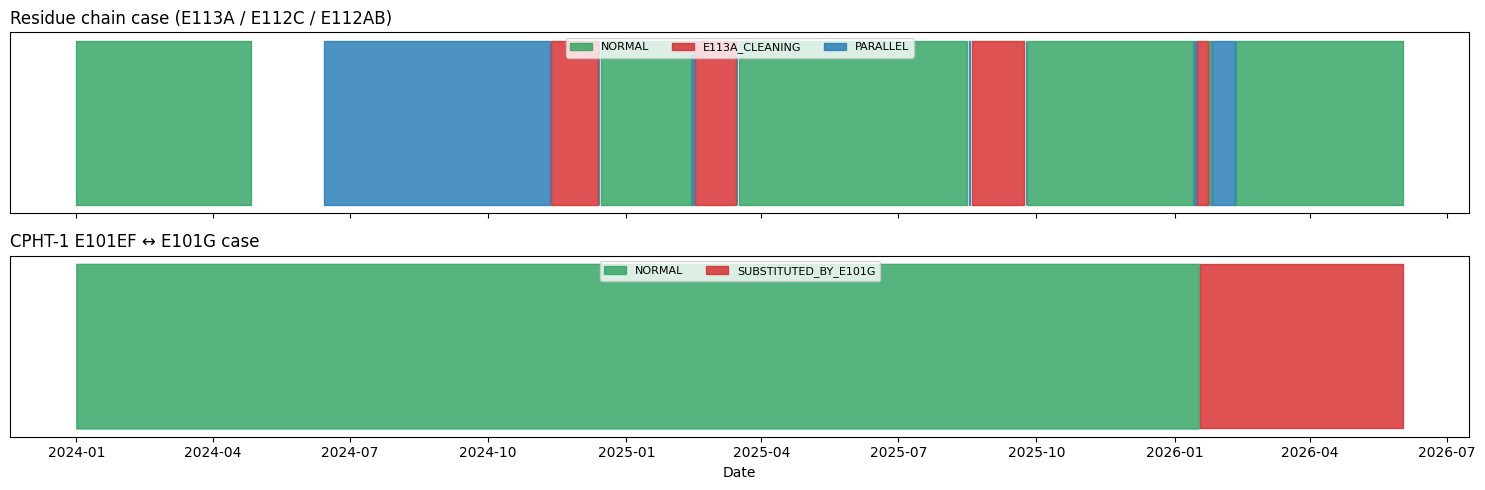

In [8]:
fig, ax = plt.subplots(2,1,figsize=(15,5),sharex=True)
# residue chain case bands
palette={'NORMAL':'#2ca25f','E113A_CLEANING':'#d62728','E112AB_CLEANING':'#9467bd',
         'PARALLEL':'#1f77b4','CHAIN_OFF_ERROR':'#000000'}
for case,color in palette.items():
    m = residue_chain_case==case
    if m.any(): ax[0].fill_between(df.index,0,1,where=m,color=color,step='mid',alpha=.8,label=case)
ax[0].set_yticks([]); ax[0].set_title('Residue chain case (E113A / E112C / E112AB)',loc='left')
ax[0].legend(ncol=5,fontsize=8,loc='upper center')
# E101EF/G case
p2={'NORMAL':'#2ca25f','OFF':'#ff7f0e','SUBSTITUTED_BY_E101G':'#d62728'}
efc=pd.Series(e101ef_case,index=df.index)
for case,color in p2.items():
    m=efc==case
    if m.any(): ax[1].fill_between(df.index,0,1,where=m,color=color,step='mid',alpha=.8,label=case)
ax[1].set_yticks([]); ax[1].set_title('CPHT-1 E101EF ↔ E101G case',loc='left')
ax[1].legend(ncol=3,fontsize=8,loc='upper center'); ax[1].set_xlabel('Date')
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR,'01_case_operate_timeline.png'),bbox_inches='tight'); plt.show()

## Step 1 done → Output
`Operating_State.csv` now carries the canonical **`residue_chain_case`** + **`e101ef_case`** columns.
**Next (Step 2):** `02_engineering_features_Q.ipynb` — single-source Q using this case mask
(exclude `CHAIN_OFF_ERROR` and `SUBSTITUTED_BY_E101G` days from fitting).
